# Correlated Combination of Statistical Models

This notebook shows how to combine several `spey` statistical models that **share
parameters** — a common signal strength, EFT Wilson coefficients appearing in more
than one analysis, or an ordinary nuisance parameter such as a shared luminosity or
jet-energy-scale uncertainty.

`spey` ships two combiners:

| | assumption | class |
|---|---|---|
| uncorrelated | analyses share **no** parameters; nuisances profiled separately | `UnCorrStatisticsCombiner` |
| correlated | user-declared parameters are **identified** across analyses and profiled jointly | `CorrelatedStatisticsCombiner` (`default.correlated_combiner`) |

The correlated combiner is a **plug-in** (it inherits `spey.BackendBase`), so the
combination is an ordinary `StatisticalModel`: every tool in `spey` — likelihoods,
CLs, upper limits, Asimov data, and `find_contour` — works on it unchanged.

---

## Contents

1. [How the combination works](cc-how)
2. [Experimental setup](cc-setup)
3. [Declaring shared parameters](cc-declare)
4. [Inspecting the combined parameter vector](cc-inspect)
5. [Checking the likelihood, gradient and Hessian](cc-check)
6. [Correlated vs uncorrelated](cc-contrast)
7. [Hypothesis testing and confidence contours](cc-contour)
8. [Backends, gradients and other frameworks](cc-backends)

(cc-how)=
## 1 · How the combination works

### The gather map

Every constituent model $m$ keeps its own local parameter vector
$\boldsymbol\theta_m \in \mathbb{R}^{n_m}$ — whatever its own backend declares in
`ModelConfig`. The combiner builds one global vector
$\mathbf{p} \in \mathbb{R}^{N}$ plus an integer **gather map** $I_m$ with

$$\theta_{m,j} = p_{I_m[j]}.$$

Two models share a parameter precisely when their maps point at the same global
slot. Anything not declared as shared gets a private slot, so $N \le \sum_m n_m$,
with equality when nothing is shared.

### The joint likelihood

Given the parameters, the observations of different analyses are independent, so the
joint likelihood still factorises over models:

$$\ln\mathcal{L}(\mathbf{p}) = \sum_m \ln\mathcal{L}_m\!\left(\mathbf{p}[I_m]\right).$$

The correlation is *not* in the observations — it comes entirely from the
identification $\theta_{m,j} = p_{I_m[j]}$. A shared nuisance parameter is profiled
**once, jointly** over all analyses that use it, instead of independently per
analysis. That is exactly the difference from `UnCorrStatisticsCombiner`.

### Derivatives: the chain rule is a scatter-add

Because the global→local map is a pure gather, its Jacobian is a selection matrix,

$$\frac{\partial \theta_{m,j}}{\partial p_a} = \delta_{I_m[j],\,a},$$

so the chain rule collapses to an accumulation with no matrix products at all:

$$\frac{\partial \ln\mathcal{L}}{\partial p_a} = \sum_m \sum_j g_{m,j}\,\delta_{I_m[j],a},
\qquad
\frac{\partial^2 \ln\mathcal{L}}{\partial p_a \partial p_b} = \sum_m \sum_{j,k} H^{(m)}_{jk}\,\delta_{I_m[j],a}\,\delta_{I_m[k],b}.$$

In practice the gradient is one `numpy.bincount` over the concatenated index maps and
the Hessian is each model's $n_m\times n_m$ block added into the
`np.ix_(I_m, I_m)` sub-block of the global matrix. A shared slot therefore simply
**sums** the contributions of every model that owns it.

In [1]:
import warnings

warnings.filterwarnings("ignore")  # keep optimiser chatter out of the notebook

import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

import spey

# `default.correlated_combiner` ships with spey as an entry point. When running from a
# source checkout whose entry points have not been refreshed, register it by hand so
# that `spey.get_backend` can still find it.
if "default.correlated_combiner" not in spey.AvailableBackends():
    spey.register_backend(spey.CorrelatedStatisticsCombiner)

print(f"Spey version : {spey.__version__}")
print(f"Combiner available : {'default.correlated_combiner' in spey.AvailableBackends()}")

Spey version : 0.2.7
Combiner available : True


(cc-setup)=
## 2 · Experimental setup

Three independent analyses probe the same EFT. Each one measures a different set of
bins and depends on the Wilson coefficients in a **different functional way** —
which is the whole point: the combiner never assumes the models look alike, it only
needs to know which parameters are the same.

| analysis | bins | local parameters | signal |
|---|---|---|---|
| `SR_A` | 2 | $\mu, c_1, c_2$ | $c_1 a_1 + c_2 a_2 + c_1 c_2 a_{12}$ (interference) |
| `SR_B` | 3 | $\mu, c_1, c_3$ | $c_1^2 b_1 + c_3 b_3$ |
| `SR_C` | 2 | $\mu, c_2$ | $c_2 d_1 + c_2^2 d_2$ |

Each model is a Gaussian likelihood with fixed per-bin widths and expected yields
$\lambda = \mu\,s(c) + b$. The signal strength $\mu$ is common to all three,
$c_1$ is measured by `SR_A` and `SR_B`, $c_2$ by `SR_A` and `SR_C`, while $c_3$ is
only accessible to `SR_B`.

In [2]:
# ── SR_A: 2 bins, c1-c2 interference ─────────────────────────────────────────
bkg_A, unc_A, obs_A = (
    np.array([50.0, 48.0]),
    np.array([7.0, 6.0]),
    np.array([63.0, 55.0]),
)
a1, a2, a12 = np.array([12.0, 15.0]), np.array([6.0, 16.0]), np.array([2.0, -3.0])

# ── SR_B: 3 bins, quadratic in c1 ────────────────────────────────────────────
bkg_B, unc_B, obs_B = (
    np.array([30.0, 22.0, 17.0]),
    np.array([5.0, 4.5, 4.0]),
    np.array([35.0, 20.0, 21.0]),
)
b1, b3 = np.array([4.0, 3.0, 2.0]), np.array([1.0, 5.0, 7.0])

# ── SR_C: 2 bins, quadratic in c2 ────────────────────────────────────────────
bkg_C, unc_C, obs_C = (
    np.array([80.0, 65.0]),
    np.array([9.0, 8.0]),
    np.array([92.0, 60.0]),
)
d1, d2 = np.array([10.0, 4.0]), np.array([1.5, 2.5])


def signal_A(pars):
    """SR_A signal; pars = (c1, c2)."""
    return pars[0] * a1 + pars[1] * a2 + pars[0] * pars[1] * a12


def signal_B(pars):
    """SR_B signal; pars = (c1, c3)."""
    return pars[0] ** 2 * b1 + pars[1] * b3


def signal_C(pars):
    """SR_C signal; pars = (c2,)."""
    return pars[0] * d1 + pars[0] ** 2 * d2


print("s_A(1,1) =", signal_A([1.0, 1.0]))
print("s_B(1,1) =", signal_B([1.0, 1.0]))
print("s_C(1)   =", signal_C([1.0]))

s_A(1,1) = [20. 28.]
s_B(1,1) = [5. 8. 9.]
s_C(1)   = [11.5  6.5]


Each analysis is an ordinary `spey` statistical model. Note that they are built
completely independently of one another — nothing here says they are related.

In [3]:
normal = spey.get_backend("default.normal")

model_A = normal(
    signal_yields=signal_A,
    background_yields=bkg_A,
    data=obs_A,
    absolute_uncertainties=unc_A,
    n_signal_parameters=2,  # c1, c2
    analysis="SR_A",
)
model_B = normal(
    signal_yields=signal_B,
    background_yields=bkg_B,
    data=obs_B,
    absolute_uncertainties=unc_B,
    n_signal_parameters=2,  # c1, c3
    analysis="SR_B",
)
model_C = normal(
    signal_yields=signal_C,
    background_yields=bkg_C,
    data=obs_C,
    absolute_uncertainties=unc_C,
    n_signal_parameters=1,  # c2
    analysis="SR_C",
)

for model in (model_A, model_B, model_C):
    print(f"{model.analysis}: {model.backend.config().parameter_names}")

SR_A: ['mu', 'signal_par_0', 'signal_par_1']
SR_B: ['mu', 'signal_par_0', 'signal_par_1']
SR_C: ['mu', 'signal_par_0']


(cc-declare)=
## 3 · Declaring shared parameters

Every model calls its own coefficients `signal_par_0`, `signal_par_1`, … so the
names alone cannot tell us what is shared: `SR_A`'s `signal_par_1` is $c_2$, while
`SR_B`'s `signal_par_1` is $c_3$. We therefore state the identification explicitly.

`shared_parameters` accepts a list whose entries may be:

| form | meaning |
|---|---|
| `"mu"` | every model owning a parameter of that **name** joins one slot |
| `{"name": "c1", "members": {"SR_A": "signal_par_0", "SR_B": 1}}` | explicit members, named global slot |
| `{"SR_A": 2, "SR_C": "signal_par_0"}` | bare mapping; the slot takes the first member's local name |
| `[("SR_A", 1), ("SR_B", 1)]` | sequence of `(model, parameter)` pairs |

A **model key** is the analysis name or the model's position; a **parameter key** is
the local parameter name or its local index. Mixing the two is fine.

```{tip}
Backends are not obliged to declare `parameter_names`. When they do not, the
combiner still exposes the parameter of interest as `"mu"` — it knows which one that
is from `ModelConfig.poi_index` — so `shared_parameters=["mu"]` works for every
backend. The remaining parameters of such a model have to be shared by index.
```

In [4]:
combiner = spey.get_backend("default.correlated_combiner")

combined = combiner(
    statistical_models=[model_A, model_B, model_C],
    shared_parameters=[
        "mu",  # common signal strength, by name
        {"name": "c1", "members": {"SR_A": "signal_par_0", "SR_B": 1}},
        {"name": "c2", "members": {"SR_A": 2, "SR_C": "signal_par_0"}},
    ],
    analysis="EFT_combination",
)
print(combined)

StatisticalModel(analysis='EFT_combination', backend=default.correlated_combiner, calculators=['toy', 'asymptotic', 'chi_square'])


(cc-inspect)=
## 4 · Inspecting the combined parameter vector

Global slots are created in first-occurrence order — model 0's parameters first —
which is why $\mu$ keeps index 0 and stays the POI.

In [5]:
backend = combined.backend

print(f"Number of parameters : {backend.npar} "
      f"(instead of {sum(m.backend.config().npar for m in (model_A, model_B, model_C))} "
      "if nothing were shared)")
print(f"Parameter names      : {backend.parameter_names}")
print(f"Shared across models : {backend.shared_parameter_names}")
print(f"POI index            : {backend.config().poi_index} "
      f"({backend.parameter_names[backend.config().poi_index]})")
print()
print("Gather maps  theta_m = p[I_m]:")
for analysis, index_map in backend.index_map.items():
    local = backend[analysis].backend.config().parameter_names
    mapped = [backend.parameter_names[i] for i in index_map]
    print(f"  {analysis}: I = {index_map.tolist()}   {local} -> {mapped}")

Number of parameters : 4 (instead of 8 if nothing were shared)
Parameter names      : ['mu', 'c1', 'c2', 'signal_par_1']
Shared across models : ['mu', 'c1', 'c2']
POI index            : 0 (mu)

Gather maps  theta_m = p[I_m]:
  SR_A: I = [0, 1, 2]   ['mu', 'signal_par_0', 'signal_par_1'] -> ['mu', 'c1', 'c2']
  SR_B: I = [0, 1, 3]   ['mu', 'signal_par_0', 'signal_par_1'] -> ['mu', 'c1', 'signal_par_1']
  SR_C: I = [0, 2]   ['mu', 'signal_par_0'] -> ['mu', 'c2']


`signal_par_1` is `SR_B`'s private coefficient $c_3$: no other analysis constrains
it, so it keeps a slot of its own. Had two models each kept a private parameter with
the same name, the combiner would qualify them as `"<analysis>::<name>"` to keep the
names unique.

(cc-check)=
## 5 · Checking the likelihood, gradient and Hessian

The combined log-pdf is just the sum of the constituent log-pdfs evaluated on their
gathered parameter vectors — let us confirm that on an arbitrary point.

In [6]:
pars = np.array([0.7, -0.4, 0.9, 1.3])  # [mu, c1, c2, c3]

by_hand = sum(
    float(backend[a].backend.get_logpdf_func()(pars[backend.index_map[a]]))
    for a in backend.analyses
)
print(f"combined logpdf : {backend.get_logpdf_func()(pars):.10f}")
print(f"sum by hand     : {by_hand:.10f}")

combined logpdf : -23.1109769378
sum by hand     : -23.1109769378


The gradient of a **shared** slot is the sum of every owner's contribution, while a
private slot receives only its own model's derivative. This is the scatter-add of
section 1 in action:

In [7]:
_, grad = backend.get_objective_function(do_grad=True)(pars)

# per-model gradients, scattered by hand into the global vector
by_hand_grad = np.zeros(backend.npar)
for analysis in backend.analyses:
    index_map = backend.index_map[analysis]
    local = backend[analysis].backend.get_objective_function(do_grad=True)(
        pars[index_map]
    )[1]
    for position, slot in enumerate(index_map):
        by_hand_grad[slot] += local[position]

print(f"{'parameter':<14}{'combined':>14}{'scattered':>14}{'owners':>10}")
for slot, name in enumerate(backend.parameter_names):
    owners = sum(slot in set(backend.index_map[a]) for a in backend.analyses)
    print(f"{name:<14}{grad[slot]:>14.6f}{by_hand_grad[slot]:>14.6f}{owners:>10}")

parameter           combined     scattered    owners
mu                  3.728279      3.728279         3
c1                 -3.093014     -3.093014         2
c2                 -0.795031     -0.795031         2
signal_par_1        1.882609      1.882609         1


The Hessian follows the same rule, block by block. Note the structural zero: $c_2$
and $c_3$ never appear in the *same* analysis, so no model can contribute a mixed
second derivative for that pair.

In [8]:
hessian = backend.get_hessian_logpdf_func()(pars)

names = backend.parameter_names
print("Hessian of logL")
print("           " + "".join(f"{n:>14}" for n in names))
for row, name in enumerate(names):
    print(f"{name:<11}" + "".join(f"{value:>14.4f}" for value in hessian[row]))

Hessian of logL
                       mu            c1            c2  signal_par_1
mu               -12.3818        3.5873       -3.6699       -6.8351
c1                 3.5873       -5.4485       -3.2446        0.6961
c2                -3.6699       -3.2446       -6.1890        0.0000
signal_par_1       -6.8351        0.6961        0.0000       -2.1252


(cc-contrast)=
## 6 · Correlated vs uncorrelated

Identifying parameters is a physical statement, not a relabelling. The clearest case
is a **common systematic**: two signal regions that share one luminosity uncertainty.

Both combiners share the signal strength $\mu$. The only difference is what happens
to the systematic: `UnCorrStatisticsCombiner` profiles a *separate* nuisance parameter
per region, while the correlated combiner profiles **one** nuisance shared by both —
which is what "the same luminosity uncertainty" actually means.

To make the consequence visible we let the two regions pull that systematic in
opposite directions: `SR_A` sees an excess (140 observed on 100 expected) while
`SR_B` sees a deficit (70 on 100), both with a 30 % background uncertainty.

In [9]:
uncorrelated_background = spey.get_backend("default.uncorrelated_background")

region_A = uncorrelated_background(
    signal_yields=[20.0],
    background_yields=[100.0],
    data=[140],  # excess: pulls the shared systematic up
    absolute_uncertainties=[30.0],
    analysis="SR_A",
)
region_B = uncorrelated_background(
    signal_yields=[20.0],
    background_yields=[100.0],
    data=[70],  # deficit: pulls the shared systematic down
    absolute_uncertainties=[30.0],
    analysis="SR_B",
)

correlated = combiner(
    statistical_models=[region_A, region_B],
    shared_parameters=[
        "mu",
        # local index 1 is each region's single nuisance parameter
        {"name": "theta_lumi", "members": {"SR_A": 1, "SR_B": 1}},
    ],
    analysis="shared_systematic",
)
uncorrelated = spey.UnCorrStatisticsCombiner(region_A, region_B)

print(f"correlated   : {correlated.backend.npar} parameters "
      f"{correlated.backend.parameter_names}")
print("uncorrelated : 2 x 2 parameters (each region keeps its own nuisance)")

correlated   : 2 parameters ['mu', 'theta_lumi']
uncorrelated : 2 x 2 parameters (each region keeps its own nuisance)


In [10]:
rows = [
    ("correlated", correlated),
    ("uncorrelated", uncorrelated),
]
print(f"{'':<16}{'muhat':>10}{'NLL':>10}{'CLs':>10}{'UL on mu':>11}")
for label, model in rows:
    print(
        f"{label:<16}{model.maximize_likelihood()[0]:>10.4f}"
        f"{model.maximize_likelihood(return_nll=True)[1]:>10.4f}"
        f"{model.exclusion_confidence_level()[0]:>10.4f}"
        f"{model.poi_upper_limit():>11.4f}"
    )

                     muhat       NLL       CLs   UL on mu


correlated          0.2500   20.1655    0.5055     2.4413


uncorrelated        0.1953    9.4924    0.5482     2.3707


Sharing the systematic makes the fit **worse**, and that is the point. With two
independent nuisance parameters each region can quietly absorb its own deviation, so
the uncorrelated combination reaches a much lower NLL — extra freedom, not extra
information. Forcing a single $\theta_{\rm lumi}$ means no value can explain an
excess in one region and a deficit in the other at the same time, and the tension
shows up honestly in the likelihood and shifts $\hat\mu$, the CLs value, and the
upper limit.

```{warning}
The converse also holds: treating genuinely shared nuisance parameters as
independent is the assumption `UnCorrStatisticsCombiner` documents, and it makes the
combination over-confident. Which combiner is right is a statement about the
experiment, not about convenience.
```

(cc-contour)=
## 7 · Hypothesis testing and confidence contours

The combination is a `StatisticalModel`, so nothing about the downstream API changes.

In [11]:
muhat, nll_min = combined.maximize_likelihood(return_nll=True)

print("available calculators :", combined.available_calculators)
print(f"NLL at mu = 1         : {combined.likelihood(1.0):.4f}")
print(f"muhat                 : {muhat:.4f}   (NLL = {nll_min:.4f})")
print(f"chi2 at mu = 1        : {combined.chi2(1.0):.4f}")
print("Asimov data           :", np.round(combined.generate_asimov_data(), 2))

available calculators : ['toy', 'asymptotic', 'chi_square']
NLL at mu = 1         : 21.0750
muhat                 : 0.1734   (NLL = 20.8162)
chi2 at mu = 1        : 0.5176
Asimov data           : [50. 48. 30. 22. 17. 80. 65.]


A CLs limit **on $\mu$** is not meaningful for *this* model, and the reason is worth
understanding. The expected yields are $\lambda = \mu\,s(c) + b$, so rescaling the
coefficients largely compensates a change in $\mu$ — the two are nearly degenerate.
Profiling the coefficients therefore leaves the likelihood almost flat in $\mu$:

In [12]:
print(f"{'mu':>6}{'profiled NLL':>16}{'q = 2 dNLL':>14}")
for mu in [0.5, 1.0, 2.0, 5.0]:
    nll = combined.likelihood(mu)
    print(f"{mu:>6.1f}{nll:>16.4f}{2 * (nll - nll_min):>14.4f}")

    mu    profiled NLL    q = 2 dNLL
   0.5         20.9690        0.3056
   1.0         21.0750        0.5176
   2.0         21.1413        0.6502
   5.0         21.1844        0.7363


```{warning}
The test statistic barely grows between $\mu = 0.5$ and $\mu = 5$, so these data do
not bound $\mu$ from above and the CLs root-finder has no well-defined crossing to
locate — `poi_upper_limit` would return a spurious root. This is a property of the
EFT parameterisation, not of the combiner: the single-model case in the
[multi-parameter contour tutorial](multiparameter_contour.ipynb) behaves the same way,
which is exactly why it fixes $\mu=1$ and maps a contour instead.

Section 6 is the opposite situation: there $\mu$ is the only parameter of interest,
the profile likelihood is well behaved in it, and the CLs value and upper limit in
that table are exactly what one wants.
```

The meaningful statement here is a **confidence region in coefficient space**, which
is what we compute below.

Individual parameters can be fixed by **name** through the usual multi-POI
interface, using the global names the combiner assigned:

In [13]:
print("NLL with c1 = c2 = 0.5, mu = 1 :",
      f"{combined.likelihood({'mu': 1.0, 'c1': 0.5, 'c2': 0.5}):.4f}")

NLL with c1 = c2 = 0.5, mu = 1 : 21.4025


`find_contour` works too. It fixes $\mu = 1$ and maps the 95 % CL boundary in the
remaining 3-dimensional coefficient space $(c_1, c_2, c_3)$ — a genuine *combined*
EFT constraint, since each point on the surface must be compatible with all three
analyses simultaneously. See the
[multi-parameter contour tutorial](multiparameter_contour.ipynb) for the algorithm.

In [14]:
from spey.multiparameter import find_contour

result = find_contour(
    combined,
    confidence_level=0.95,
    n_radial=300,  # rays shot from the MLE
    n_hmc_chains=3,  # RATTLE chains seeded in the angular gaps
    n_hmc_steps=150,
    n_gap_candidates=400,
    n_multistart=5,  # the defaults (20 restarts, 2 coverage passes) are much
    n_coverage_passes=1,  # slower; raise them for a production-quality surface
    random_seed=42,
    n_jobs=1,
)
print(f"contour parameters : {result.parameter_names}")
print(f"degrees of freedom : {result.dof}")
print(f"NLL at MLE         : {result.nll_min:.4f}")
print(f"NLL threshold      : {result.threshold:.4f}")
print(f"contour points     : {len(result.contour_points)}")

Running HMC Chain:   0%|                    | 0/3 [00:00<?, ?it/s]

Running HMC Chain:  33%|██████▋             | 1/3 [00:00<00:01,  1.65it/s]

Running HMC Chain:  67%|█████████████▎      | 2/3 [00:01<00:00,  1.60it/s]

Running HMC Chain: 100%|████████████████████| 3/3 [00:01<00:00,  1.61it/s]

Running HMC Chain: 100%|████████████████████| 3/3 [00:01<00:00,  1.61it/s]

contour parameters : ['c1', 'c2', 'signal_par_1']
degrees of freedom : 3
NLL at MLE         : 21.0750
NLL threshold      : 24.9824
contour points     : 753


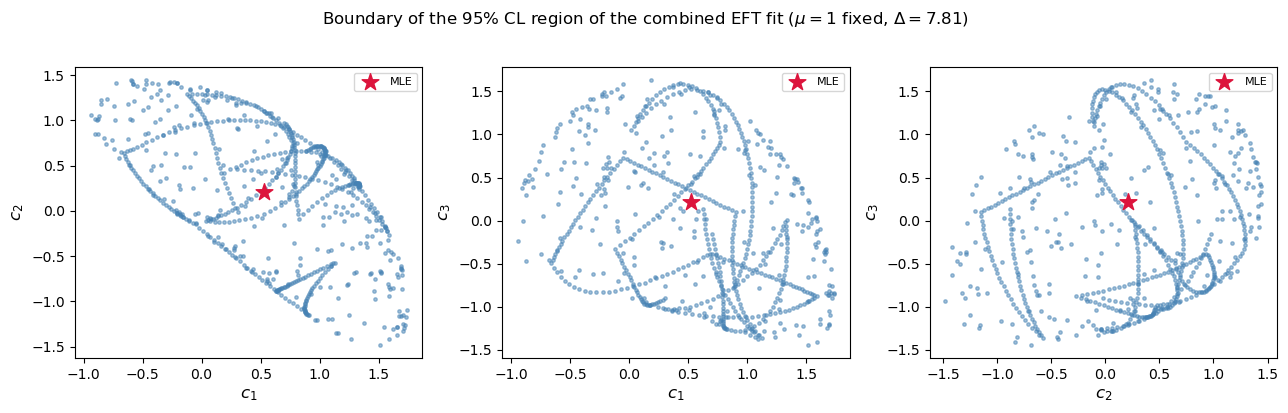

In [15]:
points, mle = result.contour_points, result.theta_mle
labels = [r"$c_1$", r"$c_2$", r"$c_3$"]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle(
    "Boundary of the 95% CL region of the combined EFT fit "
    rf"($\mu=1$ fixed, $\Delta={result.delta:.2f}$)",
    y=1.02,
)
for ax, (i, j) in zip(axes, combinations(range(3), 2)):
    ax.scatter(points[:, i], points[:, j], s=6, alpha=0.5, color="steelblue")
    ax.scatter(mle[i], mle[j], s=160, marker="*", color="crimson", zorder=5, label="MLE")
    ax.set_xlabel(labels[i], fontsize=12)
    ax.set_ylabel(labels[j], fontsize=12)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

(cc-backends)=
## 8 · Backends, gradients and other frameworks

**Any mix of backends.** The constituents may use different backends —
`default.normal` here, but equally `default.uncorrelated_background`, a `pyhf`
workspace via `spey-pyhf`, or your own plug-in. The combiner only talks to the
`BackendBase` interface.

**Shared nuisance parameters.** Nothing above is specific to parameters of
interest. To tie the same nuisance parameter across two analyses, point at it by
index:

```python
combiner(
    statistical_models=[analysis_1, analysis_2],
    shared_parameters=[
        "mu",
        {"name": "lumi", "members": {"analysis_1": 1, "analysis_2": 1}},
    ],
    analysis="joint",
)
```

The shared nuisance is then profiled once over the joint likelihood rather than
independently in each analysis.

**Differentiability is all-or-nothing.** If every constituent provides a gradient,
the combination provides one; if a single model does not, the combined gradient is
reported as unavailable and `spey` falls back to its numerical optimiser. The same
holds for the Hessian, for `expected_data` (Asimov data) and for `get_sampler`
(toys) — which is why `available_calculators` above tells you what the combination
can really do.

In [16]:
print("gradient available :", backend.is_differentiable)
print("Hessian available  :", backend.is_hessian_available)

gradient available : True
Hessian available  : True


**Other autodiff frameworks.** A backend may compute its derivatives with `jax`,
`tensorflow`, `pytorch`, or in closed form. The combiner never differentiates
*through* a backend — it only consumes the gradient and Hessian that the backend
advertises, and converts whatever object comes back (device arrays, tensors carrying
a gradient tape) into `numpy`. Conversely, a backend is only ever handed a plain
`float64` array, never an `autograd` box, because the combined log-pdf is registered
as an `autograd` primitive with hand-wired vector-Jacobian products. That is also
what lets `find_contour` — which differentiates the log-pdf externally — work above
even though nothing requires the constituents to use `autograd`.

**Data layout.** `expected_data` and `get_sampler` concatenate the constituent
outputs in model order, and `get_logpdf_func(data=...)` splits a combined dataset
back up the same way, so Asimov data and toys round-trip correctly.

In [17]:
asimov = backend.expected_data(np.array([1.0, 1.0, 1.0, 1.0]))
widths = [len(backend[a].backend.expected_data(np.ones(len(backend.index_map[a]))))
          for a in backend.analyses]
print(f"combined expected data ({len(asimov)} bins): {np.round(asimov, 2)}")
print(f"laid out as {dict(zip(backend.analyses, widths))}")

combined expected data (7 bins): [70.  76.  35.  30.  26.  91.5 71.5]
laid out as {'SR_A': 2, 'SR_B': 3, 'SR_C': 2}
